# 数据预处理与特征工程

本 Notebook 用于展示数据清洗、标签转换、特征构造、One-Hot 编码、训练集测试集划分等过程。

## 1. 读取必要文件

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['figure.dpi'] = 120

def find_project_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'config.yaml').exists() and (p / 'data').exists():
            return p
    return cwd

project_root = find_project_root()
raw_path = project_root / 'data' / 'raw' / 'Telco-Customer-Churn.csv'
cleaned_path = project_root / 'data' / 'processed' / 'churn_cleaned.csv'
train_path = project_root / 'data' / 'processed' / 'train.csv'
test_path = project_root / 'data' / 'processed' / 'test.csv'
feature_cols_path = project_root / 'data' / 'processed' / 'feature_columns.json'
fig_dir = project_root / 'outputs' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(raw_path)
cleaned_df = pd.read_csv(cleaned_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
feature_columns = json.loads(feature_cols_path.read_text(encoding='utf-8'))
print('项目根目录:', project_root)

项目根目录: E:\TelecomCustomer_ChurnPrediction


## 2. 维度与特征数量

In [2]:
print('原始数据维度:', raw_df.shape)
print('清洗后数据维度:', cleaned_df.shape)
print('训练集维度:', train_df.shape)
print('测试集维度:', test_df.shape)
print('特征数量:', len(feature_columns))

原始数据维度: (7043, 21)
清洗后数据维度: (7043, 26)
训练集维度: (5634, 37)
测试集维度: (1409, 37)
特征数量: 36


## 3. TotalCharges 处理逻辑验证

In [3]:
print('原始 TotalCharges 的类型:', raw_df['TotalCharges'].dtype)
total_num = pd.to_numeric(raw_df['TotalCharges'], errors='coerce')
print('转换为数值后的缺失数量:', int(total_num.isna().sum()))
print('处理说明: 使用 TotalCharges 中位数填补缺失值。')

原始 TotalCharges 的类型: str
转换为数值后的缺失数量: 11
处理说明: 使用 TotalCharges 中位数填补缺失值。


## 4. Churn 标签转换

In [4]:
print('标签映射: Yes -> 1, No -> 0')
display(cleaned_df['Churn'].value_counts().sort_index().rename('样本数').to_frame())

标签映射: Yes -> 1, No -> 0


,样本数
Churn,
0,5174
1,1869


## 5. 业务特征工程表

In [5]:
feature_logic_df = pd.DataFrame([
    {'特征名': 'service_count', '构造逻辑': '统计多个服务字段中 Yes 的数量', '业务含义': '衡量客户服务绑定程度'},
    {'特征名': 'avg_monthly_charge', '构造逻辑': 'TotalCharges / tenure，tenure 为 0 时用 MonthlyCharges', '业务含义': '衡量客户平均消费压力'},
    {'特征名': 'is_month_to_month', '构造逻辑': 'Contract 是否为 Month-to-month', '业务含义': '衡量合约约束强弱'},
    {'特征名': 'has_internet_service', '构造逻辑': 'InternetService 是否不为 No', '业务含义': '衡量是否使用互联网服务'},
    {'特征名': 'is_auto_payment', '构造逻辑': 'PaymentMethod 是否包含 automatic', '业务含义': '衡量自动续费和支付便利性'},
    {'特征名': 'high_charge_low_tenure', '构造逻辑': 'MonthlyCharges 高于中位数且 tenure 低于中位数', '业务含义': '识别高消费但低黏性的潜在风险客户'},
])
display(feature_logic_df)

,特征名,构造逻辑,业务含义
0,service_count,统计多个服务字段中 Yes 的数量,衡量客户服务绑定程度
1,avg_monthly_charge,TotalCharges / tenure，tenure 为 0 时用 MonthlyCha...,衡量客户平均消费压力
2,is_month_to_month,Contract 是否为 Month-to-month,衡量合约约束强弱
3,has_internet_service,InternetService 是否不为 No,衡量是否使用互联网服务
4,is_auto_payment,PaymentMethod 是否包含 automatic,衡量自动续费和支付便利性
5,high_charge_low_tenure,MonthlyCharges 高于中位数且 tenure 低于中位数,识别高消费但低黏性的潜在风险客户


## 6. 构造特征描述性统计

In [6]:
feature_cols = ['service_count', 'avg_monthly_charge', 'is_month_to_month', 'has_internet_service', 'is_auto_payment', 'high_charge_low_tenure']
display(cleaned_df[feature_cols].describe(include='all'))
for col in ['service_count', 'is_month_to_month', 'has_internet_service', 'is_auto_payment', 'high_charge_low_tenure']:
    print(f'\n{col} 分布:')
    display(cleaned_df[col].value_counts(dropna=False).rename('count').to_frame())

,service_count,avg_monthly_charge,is_month_to_month,has_internet_service,is_auto_payment,high_charge_low_tenure
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,3.362914,64.762906,0.550192,0.783331,0.435326,0.204600
std,2.062031,30.189796,0.497510,0.412004,0.495835,0.403438
min,0.000000,13.775000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,35.935156,0.000000,1.000000,0.000000,0.000000
50%,3.000000,70.337500,1.000000,1.000000,0.000000,0.000000
75%,5.000000,90.174158,1.000000,1.000000,1.000000,0.000000
max,8.000000,121.400000,1.000000,1.000000,1.000000,1.000000



service_count 分布:


,count
service_count,
1,1701
2,1188
3,965
4,922
5,908
6,676
7,395
8,208
0,80



is_month_to_month 分布:


,count
is_month_to_month,
1,3875
0,3168


...

,count
has_internet_service,
1,5517
0,1526



is_auto_payment 分布:


,count
is_auto_payment,
0,3977
1,3066



high_charge_low_tenure 分布:


,count
high_charge_low_tenure,
0,5602
1,1441


## 7. One-Hot 编码后特征列数量

In [7]:
print('特征列数量:', len(feature_columns))
print('前 15 个特征名:')
for i, col in enumerate(feature_columns[:15], start=1):
    print(f'{i:02d}. {col}')

特征列数量: 36
前 15 个特征名:
01. SeniorCitizen
02. tenure
03. MonthlyCharges
04. TotalCharges
05. service_count
06. avg_monthly_charge
07. is_month_to_month
08. has_internet_service
09. is_auto_payment
10. high_charge_low_tenure
11. gender_Male
12. Partner_Yes
13. Dependents_Yes
14. PhoneService_Yes
15. MultipleLines_No phone service


## 8. 训练集与测试集标签分布

,train_ratio,test_ratio
Churn,,
0,0.734647,0.734564
1,0.265353,0.265436


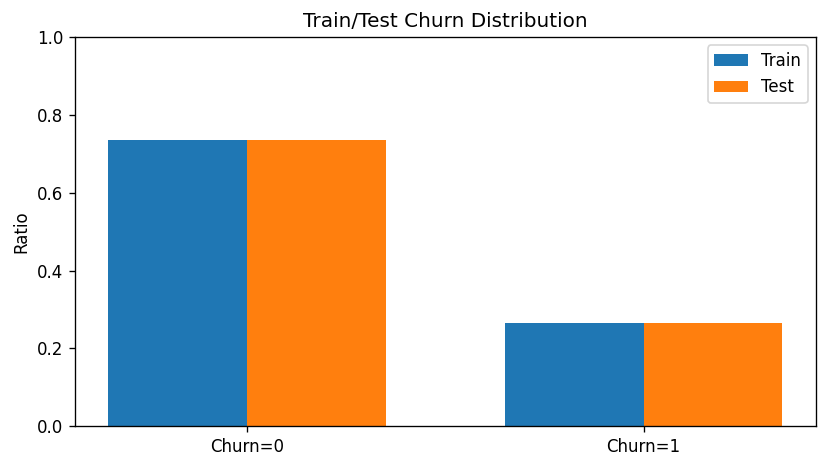

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\preprocess_train_test_churn_distribution.png


In [8]:
train_rate = train_df['Churn'].value_counts(normalize=True).sort_index().rename('train_ratio')
test_rate = test_df['Churn'].value_counts(normalize=True).sort_index().rename('test_ratio')
dist_df = pd.concat([train_rate, test_rate], axis=1).fillna(0)
dist_df.index.name = 'Churn'
display(dist_df)

x = [0, 1]
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - w/2 for i in x], [float(train_rate.get(i, 0)) for i in x], width=w, label='Train')
ax.bar([i + w/2 for i in x], [float(test_rate.get(i, 0)) for i in x], width=w, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(['Churn=0', 'Churn=1'])
ax.set_ylim(0, 1)
ax.set_ylabel('Ratio')
ax.set_title('Train/Test Churn Distribution')
ax.legend()
fig.tight_layout()
out_path = fig_dir / 'preprocess_train_test_churn_distribution.png'
fig.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)

## 9. 业务构造特征分布图

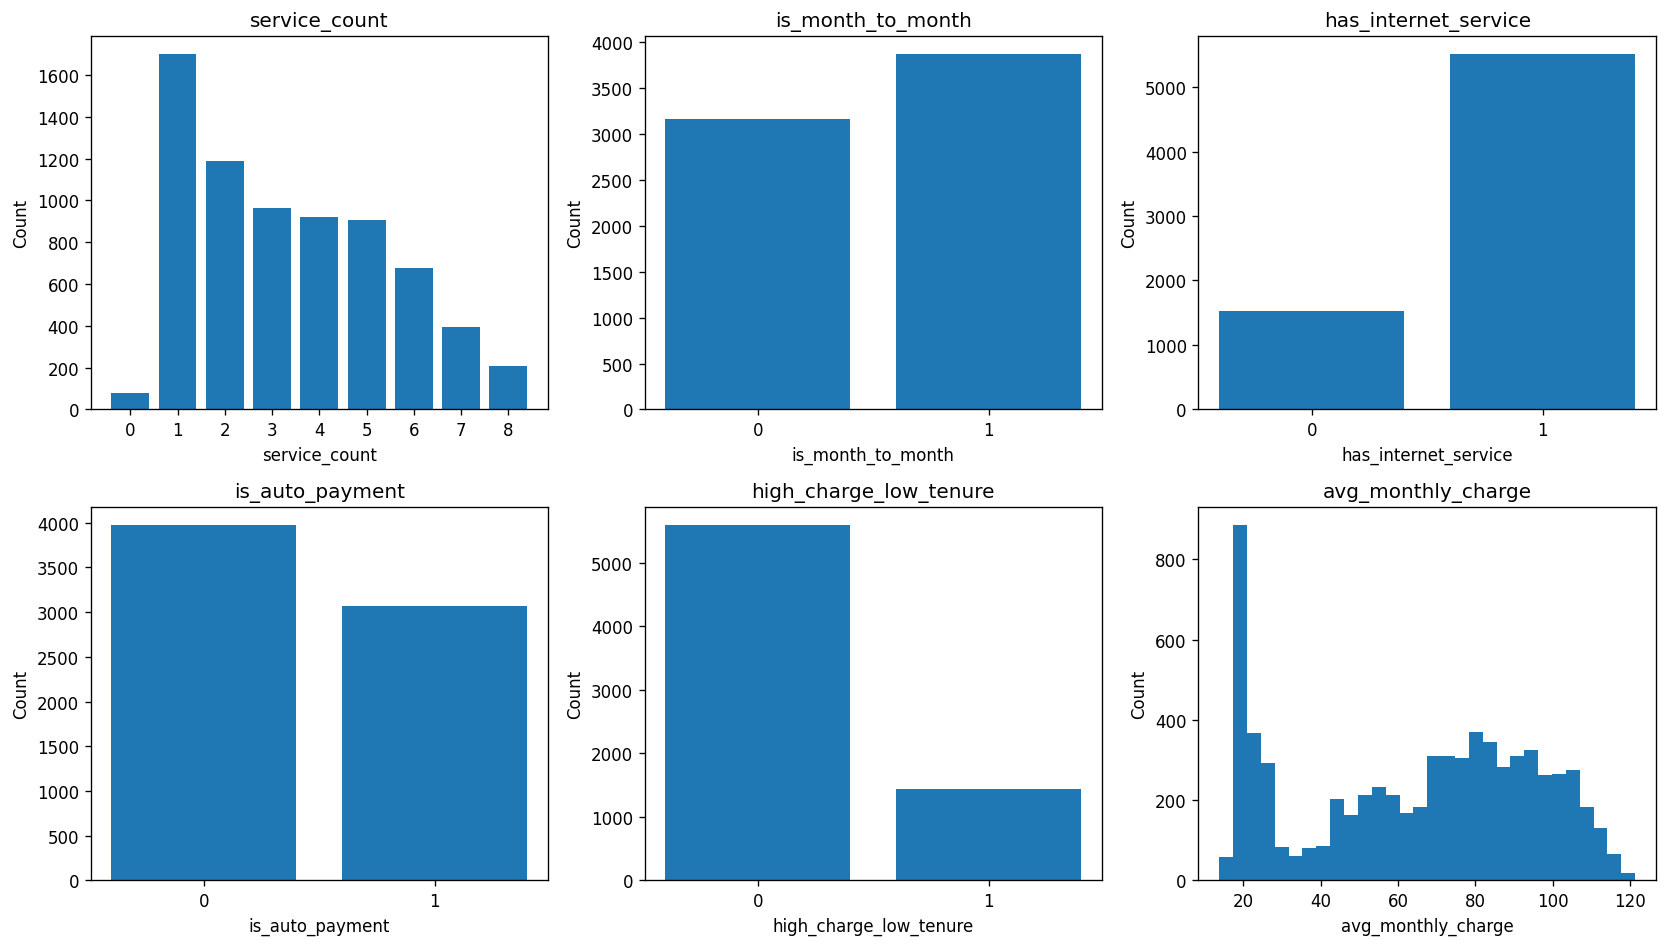

已保存图表: E:\TelecomCustomer_ChurnPrediction\outputs\figures\feature_engineering_business_features.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
items = [
    ('service_count', 'service_count'),
    ('is_month_to_month', 'is_month_to_month'),
    ('has_internet_service', 'has_internet_service'),
    ('is_auto_payment', 'is_auto_payment'),
    ('high_charge_low_tenure', 'high_charge_low_tenure'),
    ('avg_monthly_charge', 'avg_monthly_charge'),
]
for ax, (col, title) in zip(axes.flatten(), items):
    if cleaned_df[col].nunique() <= 10:
        vc = cleaned_df[col].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values)
        ax.set_ylabel('Count')
    else:
        ax.hist(cleaned_df[col].dropna(), bins=30)
        ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_xlabel(col)
fig.tight_layout()
out_path = fig_dir / 'feature_engineering_business_features.png'
fig.savefig(out_path, dpi=150)
plt.show()
print('已保存图表:', out_path)

## 10. 结论
- 数据清洗解决了 TotalCharges 类型和缺失值问题。
- 标签编码将流失预测转化为二分类任务。
- 业务特征工程增强了模型对客户黏性、消费压力、合约约束和服务绑定程度的刻画。
- 分层划分保持了训练集与测试集类别比例一致，为后续模型评估提供可靠基础。